# Regridding HI / foreground / noise maps to a Cartesian grid with `gridimp`

Takes the HEALPix HI, synchrotron+free-free, and noise maps used in `SMICA_HI.ipynb` and regrids them onto a shared Cartesian `(nx,ny,nz)` grid using [gridimp](https://github.com/stevecunnington/gridimp), so that a P(k) estimator can be run on them


```
conda activate gridimp
```

In [1]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy import units as u
from astropy_healpix import HEALPix

# NOTE: gridimp's own `model.py` calls cosmo.H(0) at import time, which needs
# cosmo.SetCosmology() to have already been run. So only `cosmo` is imported here;
# `grid`, `line`, `power` are imported further down, right after SetCosmology() runs.
from gridimp import cosmo

## Survey and frequency setup

Matches the values used in `SMICA_HI.ipynb`: `nside=256`, 10 MHz channels from 544-1088 MHz, and the RA/Dec patch mask.

In [2]:
nside = 256
# freqs = np.arange(544, 1088, step=10)  # MHz, channel edges as defined in SMICA_HI.ipynb
freqs = np.arange(1042,1183, step=1)  
nu = freqs[:-1].astype(float)          # channel values actually populated in the maps
                                        # (float: gridimp's comoving_dims does in-place float arithmetic on nu_p)
nfreqs = len(nu)

ramin, ramax = -60.0, 60.0    # deg
decmin, decmax = -75.0, -10.0 # deg

numin, numax = nu[0], nu[-1]
print(f"nfreqs={nfreqs}, {numin}-{numax} MHz")

nfreqs=140, 1042.0-1181.0 MHz


## Set cosmology


In [3]:
from gridimp import line
from astropy.cosmology import FlatLambdaCDM

# Cosmology used to generate the HI maps (flat LCDM, matches CAMB: H0=100*h, omch2=Oc*h**2, ombh2=Ob*h**2):
h = 0.7
Oc = 0.25
Ob = 0.05

# Set gridimp's cosmology globals directly (mirrors what cosmo.SetCosmology() does internally,
# but with the sim's actual cosmology instead of a Planck15/Planck18 preset):
cosmo.cosmo_ = FlatLambdaCDM(H0=100 * h, Om0=Oc + Ob, Ob0=Ob)
cosmo.H_0 = cosmo.cosmo_.H(0).value
cosmo.h = cosmo.H_0 / 100
cosmo.Om0 = Oc + Ob
cosmo.Ob0 = Ob
# n_s/A_s are only used by cosmo.GetModelPk() (not called in this notebook) - if you use that later,
# set these to match the primordial parameters from your sim too:
# cosmo.n_s = 0.965
# cosmo.A_s = 2.14e-9

zmin, zmax = line.nu21cm_to_z(numax), line.nu21cm_to_z(numin)
zeff = np.mean([zmin, zmax])
print(f"Frequency range {numin}-{numax} MHz -> redshift range {zmin:.3f} < z < {zmax:.3f} (zeff={zeff:.3f})")
print(f"Cosmology: H0={cosmo.H_0:.2f}, Om0={cosmo.Om0:.3f}, Ob0={cosmo.Ob0:.3f}")

# Safe to import now that cosmo_ (and friends) have been set:
from gridimp import grid, power

Frequency range 1042.0-1181.0 MHz -> redshift range 0.203 < z < 0.363 (zeff=0.283)
Cosmology: H0=70.00, Om0=0.300, Ob0=0.050


## Load simulated maps

Loads the celestial-frame (rotated) HI, foreground and noise maps that `SMICA.ipynb` already caches, so the
RA/Dec patch mask below (defined in celestial coordinates) selects the same patch of sky as the SMICA fit --
the raw simulated maps are in galactic coordinates and must not be masked with this RA/Dec box directly.

In [4]:
input_path = "/datadec/cppm/shoaib/SMICA_Paper/data/UHF/"

# Maps are simulated in galactic coordinates; the RA/Dec patch mask below is defined in
# celestial coordinates (matches SMICA.ipynb). Load the celestial-rotated caches instead
# of the raw galactic maps -- loading the raw maps here would silently select the wrong
# patch of sky (same numeric RA/Dec box, but read off galactic lon/lat instead).
hi    = np.load(f"{input_path}/rotated_hi_1042_1183.npy")[:-1]     # mK, celestial
fgds  = np.load(f"{input_path}/rotated_fgds_1042_1183.npy")[:-1]   # mK, celestial
noise = np.load(f"{input_path}/rotated_noise_1042_1183.npy")[:-1]  # celestial (unit scaling not addressed here, see SMICA.ipynb)

dirty = hi + fgds + noise  # HI + foregrounds + noise: the "observed" cube to be cleaned downstream

assert hi.shape == (nfreqs, hp.nside2npix(nside)), hi.shape
print("map shape (nfreqs, npix):", hi.shape)

map shape (nfreqs, npix): (140, 786432)


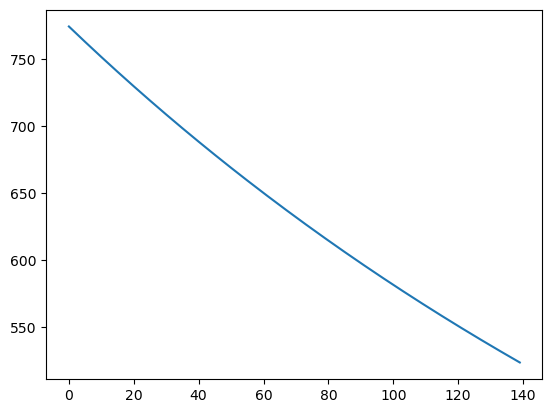

In [ ]:
plt.plot(fgds[:,32]) #thisis what my fg gridden cube should look like, 
#it matches the amp for GPR as wells so whats happening??

### Sanity-check map units

All four fields should be in mK 

In [6]:
print(f"HI    std = {np.std(hi):.4g} mK   (expect ~1e-2-1 mK: the faint cosmological signal)")
print(f"FG    std = {np.std(fgds):.4g} mK   (expect several orders of magnitude brighter than HI)")
print(f"Noise std = {np.std(noise):.4g} mK")
print(f"Dirty std = {np.std(dirty):.4g} mK   (should be dominated by FG)")

HI    std = 0.0917 mK   (expect ~1e-2-1 mK: the faint cosmological signal)
FG    std = 1890 mK   (expect several orders of magnitude brighter than HI)
Noise std = 2.004e-08 mK
Dirty std = 1890 mK   (should be dominated by FG)


## Identify sky-patch pixels and comoving box dimensions

Uses `gridimp`'s own `grid.init_healpix` for the RA/Dec patch mask (same logic as `SMICA_HI.ipynb`'s
`create_sky_patch_mask`, but keeping the pixel `(RA, Dec)` coordinates rather than a 0/1 map, since
`gridimp` needs the actual coordinates of the on-patch pixels).

In [13]:
hp0 = HEALPix(nside)

# grid.init_healpix does the same RA/Dec masking as before (wraps RA to [-180,180], cuts on
# ramin/ramax/decmin/decmax) and returns the masked pixel (ra,dec). 
ra_patch, dec_patch, _, _ = grid.init_healpix(nside, ramin, ramax, decmin, decmax, numin, numax, nnu=nfreqs, n0=2)

# ipix_patch for the pixel-counting 
ipix_patch = hp0.lonlat_to_healpix(ra_patch, dec_patch)

print(f"Patch contains {len(ipix_patch)} of {hp0.npix} HEALPix pixels")

Patch contains 103977 of 786432 HEALPix pixels


In [14]:
# Survey area and sky fraction.
# Analytic: solid angle of a RA/Dec rectangle needs the cos(Dec) weighting
# (lines of constant RA converge toward the poles), so it's not just dRA*dDec.
dra = np.radians(ramax - ramin)
dsin = np.sin(np.radians(decmax)) - np.sin(np.radians(decmin))
area_sr = dra * dsin
fullsky_deg2 = 4 * np.pi * (180 / np.pi) ** 2
area_deg2 = area_sr * (180 / np.pi) ** 2
fsky_analytic = area_deg2 / fullsky_deg2

# Cross-check via pixel counting (should closely match the analytic value):
fsky_pixel = len(ipix_patch) / hp0.npix
area_deg2_pixel = fsky_pixel * fullsky_deg2

print(f"Survey area (analytic):       {area_deg2:.1f} deg^2   (fsky = {fsky_analytic:.4f})")
print(f"Survey area (pixel counting): {area_deg2_pixel:.1f} deg^2   (fsky = {fsky_pixel:.4f})")

Survey area (analytic):       5447.3 deg^2   (fsky = 0.1320)
Survey area (pixel counting): 5454.2 deg^2   (fsky = 0.1322)


In [15]:
n_fft = 64  # output grid resolution in the two transverse (nx,ny) directions
            # nz is kept at the native frequency resolution (nfreqs) so GPR can later fit along real channels

dims_fft = grid.comoving_dims(ra_patch, dec_patch, nu, nside, ndim=(n_fft, n_fft, nfreqs))
lx, ly, lz, nx, ny, nz, x0, y0, z0 = dims_fft
print(f"Box size (Mpc/h): {lx:.1f} x {ly:.1f} x {lz:.1f}")
print(f"Grid cells: {nx} x {ny} x {nz}")

Box size (Mpc/h): 1771.5 x 1114.5 x 792.2
Grid cells: 64 x 64 x 140


## Regrid onto the Cartesian grid

`gridimp` regrids by Monte-Carlo sampling particles within each HEALPix voxel and painting them onto the FFT mesh. To keep HI, foregrounds, noise and the dirty map on *identical* sampling geometry (so, e.g., the regridded HI + foreground + noise cubes stay consistent with the regridded dirty cube), the particle positions are generated **once** and then reused to pull pixel values for every map.

In [ ]:
Np = 5          # number of sampling particles per map voxel for regridding
window = 'cic'  # mass assignment window
compensate = True  # correct for interpolaton effects at field level
interlace = True  # interlace FFT fields

# Generate shared particle positions (pixvals from this call are discarded, only used to fix geometry):
ra_p, dec_p, nu_p, _ = grid.SkyPixelParticles_healpy(ra_patch, dec_patch, nu, nside, map=hi.T, Np=Np)

xp, yp, zp = grid.SkyCoordtoCartesian(
    ra_p.to(u.deg).value, dec_p.to(u.deg).value, line.nu21cm_to_z(nu_p),
    ramean_arr=ra_patch.to(u.deg).value, decmean_arr=dec_patch.to(u.deg).value, doTile=False,
)

# Recompute the same (pixel, channel) index used internally so every map is sampled identically:
dnu = np.mean(np.diff(nu)) #channel width, nu=channel centres
nubins = np.linspace(nu[0] - dnu / 2, nu[-1] + dnu / 2, len(nu) + 1) #freq bin edges
ipix_p = hp0.lonlat_to_healpix(ra_p, dec_p) #each particles sky position to healpix pixel indices
inu_p = np.digitize(nu_p, nubins) - 1 #each particle to frequency bin index



ra_p, dec_p, nu_p = monte carlo sample particles for each voxel (pixel, channel) -> shape (Np* len(ra_patch)*nfreqd)/
xp,yp,zp -> converted from sky coords to cartesian comoving Mpc/h

rederive pixvalues for all four maps, needs pixel and channel index of every particle for every field

In [60]:
def to_cartesian(healpix_map):
    """Regrid a (nfreqs, npix) HEALPix map onto the shared Cartesian grid."""
    pixvals = healpix_map.T[ipix_p, inu_p]
    field, W, counts = grid.mesh(xp, yp, zp, pixvals, dims_fft, window, compensate, interlace, verbose=True)
    return field, W

In [34]:
hi_cube, W_fft    = to_cartesian(hi)
fg_cube, _        = to_cartesian(fgds)
noise_cube, _     = to_cartesian(noise)
dirty_cube, _     = to_cartesian(dirty)

print("Cartesian cube shape (nx,ny,nz):", hi_cube.shape)


Cartesian regridding summary:
 - Minimum number of particles in grid cell: 0.0
 - Maximum number of particles in grid cell: 952.6183587631334
 - Mean number of particles in grid cell: 282.897
 - Number of missing particles: 0

Cartesian regridding summary:
 - Minimum number of particles in grid cell: 0.0
 - Maximum number of particles in grid cell: 952.6183587631334
 - Mean number of particles in grid cell: 282.897
 - Number of missing particles: 0

Cartesian regridding summary:
 - Minimum number of particles in grid cell: 0.0
 - Maximum number of particles in grid cell: 952.6183587631334
 - Mean number of particles in grid cell: 282.897
 - Number of missing particles: 0

Cartesian regridding summary:
 - Minimum number of particles in grid cell: 0.0
 - Maximum number of particles in grid cell: 952.6183587631334
 - Mean number of particles in grid cell: 282.897
 - Number of missing particles: 0
Cartesian cube shape (nx,ny,nz): (64, 64, 140)


???? what is happening here, why isnt the window the same for every redshift? has to be because sky is curved for big patch like mine??

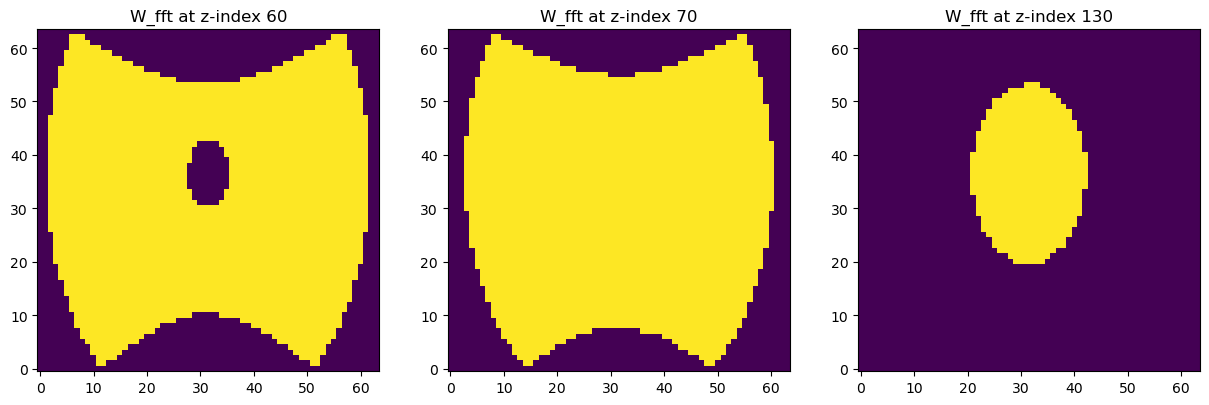

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, zi in zip(axes, [60, nz//2, nz-10]):
    ax.imshow(W_fft[:,:,zi].T, origin='lower')
    ax.set_title(f'W_fft at z-index {zi}')
plt.show()


In [36]:
print(f"x range: [{xp.min():.1f}, {xp.max():.1f}]  vs box [x0, x0+lx] = [{x0:.1f}, {x0+lx:.1f}]")
print(f"y range: [{yp.min():.1f}, {yp.max():.1f}]  vs box [y0, y0+ly] = [{y0:.1f}, {y0+ly:.1f}]")
print(f"z range: [{zp.min():.1f}, {zp.max():.1f}]  vs box [z0, z0+lz] = [{z0:.1f}, {z0+lz:.1f}]")


x range: [-863.5, 863.8]  vs box [x0, x0+lx] = [-885.8, 885.8]
y range: [-618.9, 450.0]  vs box [y0, y0+ly] = [-642.0, 472.5]
z range: [225.9, 997.2]  vs box [z0, z0+lz] = [219.7, 1011.9]


shouldnt look like this should look like smooth power law like gpr cube and my map

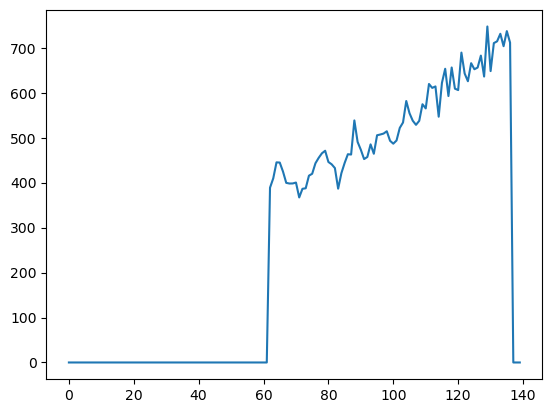

In [61]:
plt.plot(fg_cube[32,32,:]*W_fft[32,32,:])

In [ ]:
# cartesian_path="/datadec/cppm/shoaib/SMICA_Paper/data/cartesian"
# np.save(f"{cartesian_path}/hi_cube.npy", hi_cube)
# np.save(f"{cartesian_path}/fg_cube.npy", fg_cube)
# np.save(f"{cartesian_path}/noise_cube.npy", noise_cube)
# np.save(f"{cartesian_path}/dirty_cube.npy", dirty_cube)
# np.save(f"{cartesian_path}/W_fft.npy", W_fft)
# np.save(f"{cartesian_path}/dims_fft.npy", dims_fft)

## P(k) of the regridded fields

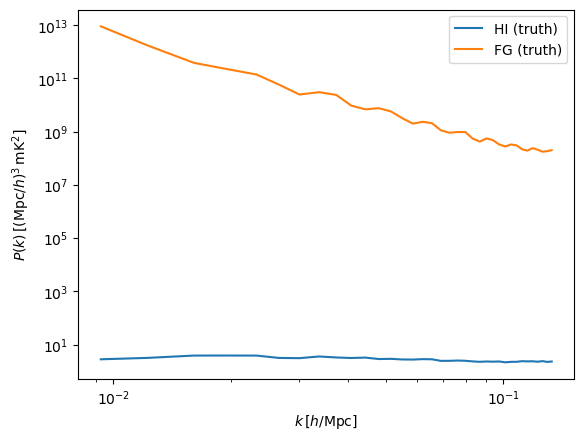

In [42]:
nyq = np.min([nx * np.pi / lx, ny * np.pi / ly, nz * np.pi / lz]) #nyquist
kmax = 1.2 * nyq
kmin = 4 * np.pi / np.max([lx, ly, lz])
deltak = kmin / 2
kbins = np.arange(kmin, kmax, deltak)

Pk_hi, k, nmodes = power.Pk(hi_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)
Pk_dirty, _, _ = power.Pk(dirty_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)
Pk_fgds, _, _ = power.Pk(fg_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)


# np.savez(f"{input_path}/Pk_hi_with_k.npz", k=k, Pk_hi=Pk_hi, nmodes=nmodes)
# np.savez(f"{input_path}/Pk_dirty_with_k.npz", k=k, Pk_dirty=Pk_dirty, nmodes=nmodes)
# np.savez(f"{input_path}/Pk_fgds_with_k.npz", k=k, Pk_fgds=Pk_fgds, nmodes=nmodes)
# print(f"Saved k and P(k) to {input_path}")

plt.plot(k, Pk_hi, label='HI (truth)')
# plt.loglog(k, Pk_dirty, label='Dirty (HI + FG + noise)')
plt.loglog(k, Pk_fgds, label='FG (truth)')
plt.xlabel(r'$k\,[h/{\rm Mpc}]$')
plt.ylabel(r'$P(k)\,[({\rm Mpc}/h)^3\,{\rm mK}^2]$')
plt.legend()
plt.show()

## P(k) parallel and perpendicular

In [43]:
from gpr4im import pk_tools as pk

kmin_par = 2*np.pi/lz
dk_par = 2*kmin_par
kmax_par = nz*np.pi/lz

kbins_par = np.arange(kmin_par, kmax_par, dk_par)
kpar_c = np.linspace(kmin_par+0.5*dk_par, kmax_par-0.5*dk_par, len(kbins_par)-1)

kmin_perp = 2*np.pi/np.sqrt(lx**2+ly**2)
dk_perp = 2*kmin_perp
kmax_perp = min(nx*np.pi/lx, ny*np.pi/ly)
kbins_perp = np.arange(kmin_perp, kmax_perp, dk_perp)
kperp_c = np.linspace(kmin_perp+0.5*dk_perp, kmax_perp-0.5*dk_perp, len(kbins_perp)-1)

hi_pk_para, nmodes_para = pk.ParaPk(hi_cube, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
hi_pk_perp, nmodes_perp = pk.PerpPk(hi_cube, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
hi_pk2d, nmodes2d = pk.PerpParaPk(hi_cube, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft)

fgds_pk_para, nmodes_para = pk.ParaPk(fg_cube, nx, ny, nz, lx, ly, lz, kbins_par, W_fft, W_fft)
fgds_pk_perp, nmodes_perp = pk.PerpPk(fg_cube, nx, ny, nz, lx, ly, lz, kbins_perp, W_fft, W_fft)
fgds_pk2d, nmodes2d = pk.PerpParaPk(fg_cube, nx, ny, nz, lx, ly, lz, kbins_perp, kbins_par, W_fft, W_fft)



Calculating P(k_perp,k_para)...

Calculating P(k_perp,k_para)...


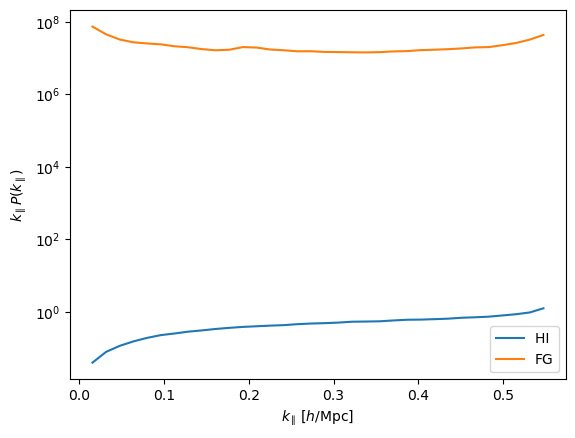

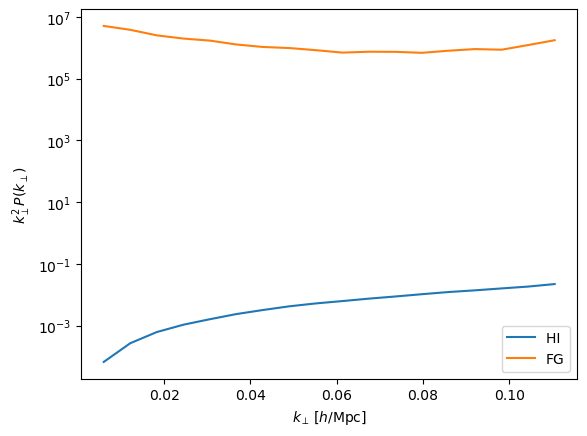

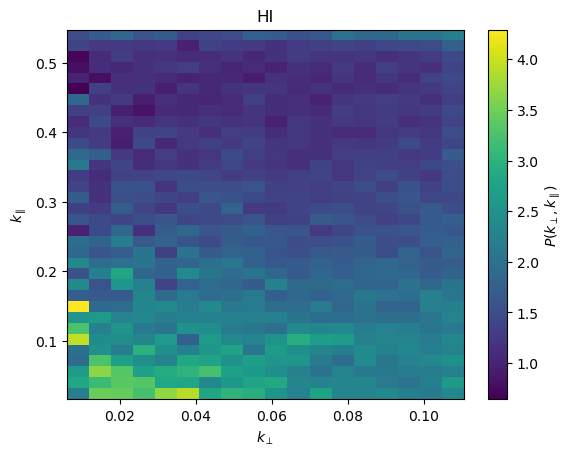

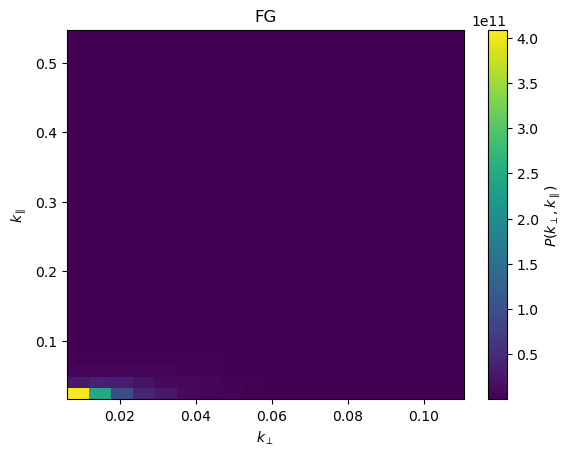

In [44]:
plt.plot(kpar_c, kpar_c*hi_pk_para, label='HI ')
plt.plot(kpar_c, kpar_c*fgds_pk_para, label='FG')
plt.xlabel(r'$k_\parallel\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\parallel P(k_\parallel)$')
plt.yscale('log')
# plt.xscale('log')
plt.legend()
plt.show()

plt.plot(kperp_c, kperp_c**2*hi_pk_perp, label='HI ')
plt.plot(kperp_c, kperp_c**2*fgds_pk_perp, label='FG')
plt.xlabel(r'$k_\perp\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\perp^2 P(k_\perp)$')
plt.yscale('log')
plt.legend()
plt.show()

plt.imshow(hi_pk2d, origin='lower', extent=[kperp_c[0],kperp_c[-1],kpar_c[0],kpar_c[-1]], aspect='auto')
plt.title('HI')
plt.xlabel(r'$k_\perp$'); plt.ylabel(r'$k_\parallel$'); plt.colorbar(label=r'$P(k_\perp,k_\parallel)$')
plt.show()

plt.imshow(fgds_pk2d, origin='lower', extent=[kperp_c[0],kperp_c[-1],kpar_c[0],kpar_c[-1]], aspect='auto')
plt.title('FG')
plt.xlabel(r'$k_\perp$'); plt.ylabel(r'$k_\parallel$'); plt.colorbar(label=r'$P(k_\perp,k_\parallel)$')
plt.show()



# GPR data visualisation

In [45]:
import pandas as pd
from gpr4im import pk_tools as pk
data = pd.read_pickle('/datadec/cppm/shoaib/gpr4im/Data/example_data.pkl')
fgds_gpr = np.array(data.beam.FGnopol)      # (128,128,142)
hi_gpr   = np.array(data.beam.HI_noise)     # (128,128,142)

lx_g, ly_g, lz_g = 500.0, 500.0, 460.77
nx_g, ny_g, nz_g = fgds_gpr.shape
w_g = W_g = np.ones((nx_g, ny_g, nz_g))

kmax_par_g  = nz_g*np.pi/lz_g
kmax_perp_g = min(nx_g*np.pi/lx_g, ny_g*np.pi/ly_g)

kmin_par_g = 2*np.pi/lz_g
dk_par_g = 2*kmin_par_g
kbins_par_g = np.arange(kmin_par_g, kmax_par_g, dk_par_g)
kpar_g = np.linspace(kmin_par_g+0.5*dk_par_g, kmax_par_g-0.5*dk_par_g, len(kbins_par_g)-1)

kmin_perp_g = 2*np.pi/np.sqrt(lx_g**2+ly_g**2)
dk_perp_g = 2*kmin_perp_g
kbins_perp_g = np.arange(kmin_perp_g, kmax_perp_g, dk_perp_g)
kperp_g = np.linspace(kmin_perp_g+0.5*dk_perp_g, kmax_perp_g-0.5*dk_perp_g, len(kbins_perp_g)-1)

fgpk_para_g, _ = pk.ParaPk(fgds_gpr, nx_g, ny_g, nz_g, lx_g, ly_g, lz_g, kbins_par_g, w_g, W_g)
fgpk_perp_g, _ = pk.PerpPk(fgds_gpr, nx_g, ny_g, nz_g, lx_g, ly_g, lz_g, kbins_perp_g, w_g, W_g)
hipk_para_g, _ = pk.ParaPk(hi_gpr, nx_g, ny_g, nz_g, lx_g, ly_g, lz_g, kbins_par_g, w_g, W_g)
hipk_perp_g, _ = pk.PerpPk(hi_gpr, nx_g, ny_g, nz_g, lx_g, ly_g, lz_g, kbins_perp_g, w_g, W_g)


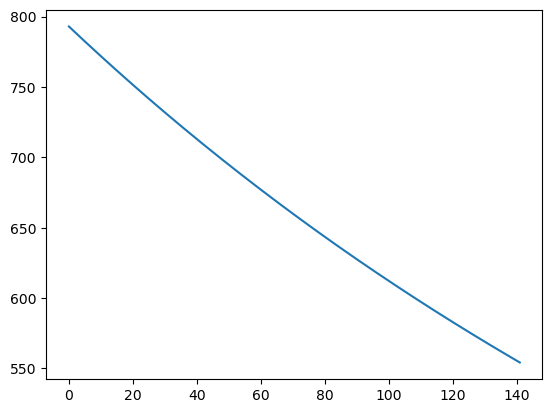

In [46]:
plt.plot(fgds_gpr[0,0,:])

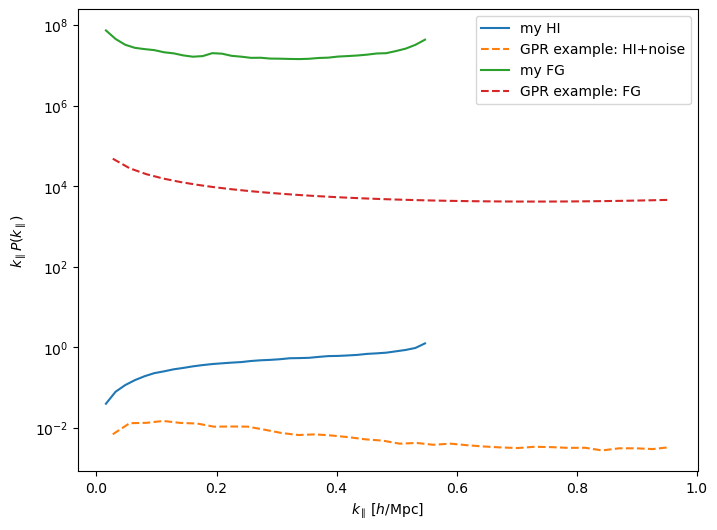

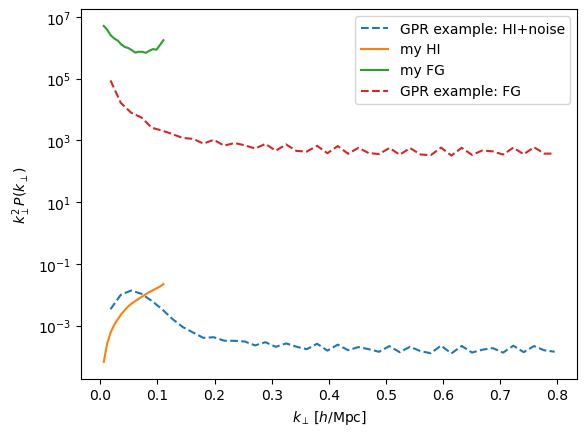

In [47]:
plt.figure(figsize=(8,6))
plt.plot(kpar_c, kpar_c*hi_pk_para, label='my HI')
plt.plot(kpar_g, kpar_g*hipk_para_g, label='GPR example: HI+noise', ls='--')
plt.plot(kpar_c, kpar_c*fgds_pk_para, label='my FG')
plt.plot(kpar_g, kpar_g*fgpk_para_g, label='GPR example: FG', ls='--')
plt.xlabel(r'$k_\parallel\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\parallel P(k_\parallel)$')
plt.yscale('log')
plt.legend(); plt.show()
plt.show()

plt.plot(kperp_g, kperp_g**2*hipk_perp_g, label='GPR example: HI+noise', ls='--')
plt.plot(kperp_c, kperp_c**2*hi_pk_perp, label='my HI')
plt.plot(kperp_c, kperp_c**2*fgds_pk_perp, label='my FG')
plt.plot(kperp_g, kperp_g**2*fgpk_perp_g, label='GPR example: FG', ls='--')
plt.xlabel(r'$k_\perp\,[h/\mathrm{Mpc}]$'); plt.ylabel(r'$k_\perp^2 P(k_\perp)$')
plt.yscale('log')
plt.legend(); plt.show()

### $\Delta^2(k)$ comparison (matches `Understanding GPR.ipynb`'s plotting convention)

`Understanding GPR.ipynb` plots the dimensionless power $\Delta^2(k) = k^3 P(k) / 2\pi^2$ on linear-linear axes, not raw $P(k)$ on log-log axes — same underlying spherically-averaged P(k), just a different (and more directly comparable to their plots) way of displaying it.

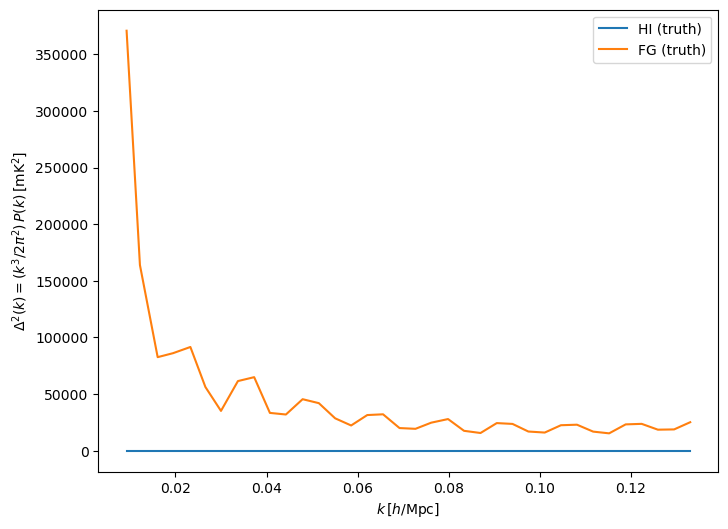

In [12]:
Pk_dirty, _, _ = power.Pk(dirty_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)
Pk_fgds, _, _ = power.Pk(fg_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)

def Delta2(pk):
    return k**3 * pk / (2 * np.pi**2)

plt.figure(figsize=(8, 6))
plt.plot(k, Delta2(Pk_hi), label='HI (truth)')
# plt.plot(k, Delta2(Pk_dirty), label='Dirty (HI + FG + noise)')
plt.plot(k, Delta2(Pk_fgds), label='FG (truth)')
plt.ylabel(r'$\Delta^2(k) = (k^3/2\pi^2)\,P(k)\,[{\rm mK}^2]$')
plt.xlabel(r'$k\,[h/{\rm Mpc}]$')
# plt.xlim(0.05, 0.4)
plt.legend()
plt.show()

## Regrid the SMICA-recovered maps and compare $P(k)$ to truth

Loads the Wiener-filter-reconstructed HI/FG maps produced in `SMICA.ipynb` (`hi_recovered.npy`/
`fg_recovered.npy`, same celestial frame as the truth cubes above) and regrids them with the identical
particle geometry (`to_cartesian`), so the recovered and truth $P(k)$ are directly comparable.

In [ ]:
hi_recovered = np.load(f"{input_path}/hi_recovered.npy")  # mK, celestial -- from SMICA.ipynb's Wiener filter
fg_recovered = np.load(f"{input_path}/fg_recovered.npy")  # mK, celestial

hi_recovered_cube, _ = to_cartesian(hi_recovered)
fg_recovered_cube, _ = to_cartesian(fg_recovered)

print("Recovered cube shape (nx,ny,nz):", hi_recovered_cube.shape)

In [ ]:
Pk_hi_recovered, _, _ = power.Pk(hi_recovered_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)
Pk_fg_recovered, _, _ = power.Pk(fg_recovered_cube, dims_fft, kbins, w1=W_fft, W1=W_fft)

plt.figure(figsize=(8, 6))
plt.plot(k, Delta2(Pk_hi), 'k-', label='HI (truth)')
plt.plot(k, Delta2(Pk_hi_recovered), '.--', label='HI (SMICA recovered)')
plt.ylabel(r'$\Delta^2(k) = (k^3/2\pi^2)\,P(k)\,[{\rm mK}^2]$')
plt.xlabel(r'$k\,[h/{\rm Mpc}]$')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(k, Delta2(Pk_fgds), 'k--', alpha=0.6, label='Foreground (truth)')
plt.plot(k, Delta2(Pk_fg_recovered), '.--', label='Foreground (SMICA recovered)')
plt.ylabel(r'$\Delta^2(k) = (k^3/2\pi^2)\,P(k)\,[{\rm mK}^2]$')
plt.xlabel(r'$k\,[h/{\rm Mpc}]$')
plt.legend()
plt.show()

## Save cubes for downstream GPR cleaning / covariance comparison

In [ ]:
out_path = f"{input_path}/cartesian"
os.makedirs(out_path, exist_ok=True)

np.save(f"{out_path}/hi_cube.npy", hi_cube)
np.save(f"{out_path}/fg_cube.npy", fg_cube)
np.save(f"{out_path}/noise_cube.npy", noise_cube)
np.save(f"{out_path}/dirty_cube.npy", dirty_cube)
np.save(f"{out_path}/W_fft.npy", W_fft)
np.save(f"{out_path}/nu.npy", nu)
np.save(f"{out_path}/dims_fft.npy", np.array(dims_fft, dtype=object))

print(f"Saved Cartesian cubes to {out_path}")